In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

In [63]:
df = pd.read_csv("Dhaka Rent.csv", sep=';')
df.head()

,area,rent
0,2000,31500
1,2100,35000
2,2500,41050
3,2250,36100
4,3000,52100


# Do experiment!

In [64]:
# Classes


#Simple Linear Reg.
class SimpleLinearReg():
    def __init__(self):
        self.coef = None
        self.intercept = None


    def fit(self, x, y):
        dev_x = x.iloc[:,0] - x.iloc[:,0].mean()
        dev_y = y - y.mean()
        m = (dev_x * dev_y).sum()/ (dev_x**2).sum()
        c = y.mean() - x.iloc[:,0].mean() * m

        self.coef = m
        self.intercept = c


    def predict(self, x):
        return (self.coef*(x.iloc[:,0]) + self.intercept)

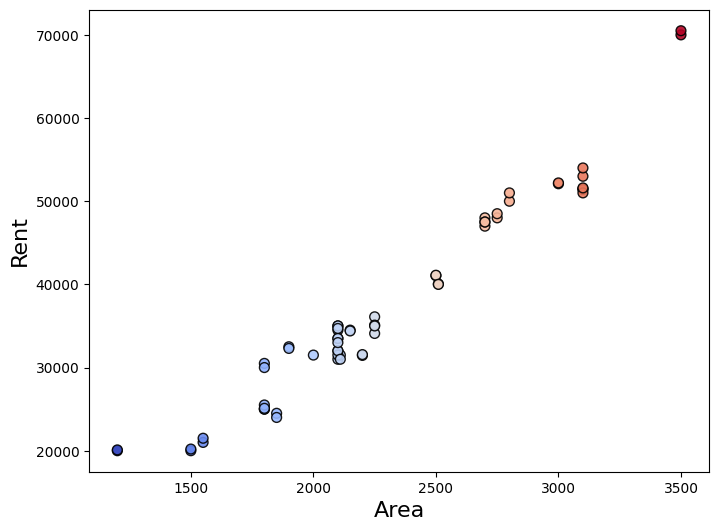

In [65]:
plt.figure(figsize=(8,6))
plt.scatter(df.iloc[:,0], 
            df.iloc[:,1],
            c=df.iloc[:,0],
            cmap="coolwarm",
            s=50,
            edgecolor="k",
            alpha=0.9
            )
plt.xlabel("Area", fontsize=16)
plt.ylabel("Rent", fontsize=16)
plt.show()

In [66]:
# Splitting data
x = df.iloc[:,[0]]
y=df.iloc[:,1]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Linear Regression

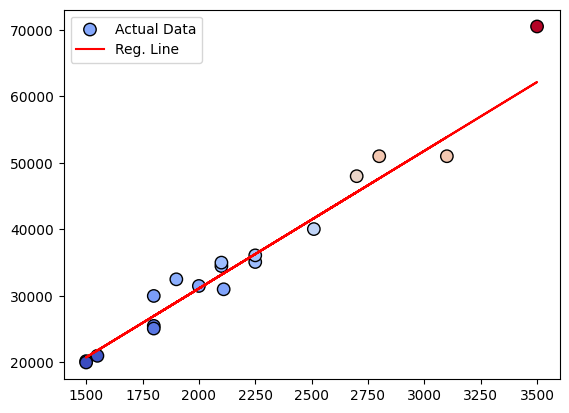

np.float64(-10252.90474033673)

In [67]:
sk_model_1 = LinearRegression()
sk_model_1.fit(x_train, y_train)
sk_model_1_coef = sk_model_1.coef_
sk_model_1_intercept = sk_model_1.intercept_

sk_model_1_pred = sk_model_1.predict(x_test)
sk_model_1_r2 = r2_score(y_test, sk_model_1_pred)

plt.scatter(x_test,
            y_test,
            label="Actual Data",
            c=y_test,
            cmap='coolwarm',
            edgecolors='k',
            s=80
            )
plt.plot(x_test, sk_model_1_pred, color='red', label="Reg. Line")
plt.legend()
plt.show()

sk_model_1_r2
sk_model_1.intercept_

In [71]:
my_model_1 = SimpleLinearReg()
my_model_1.fit(x_train, y_train)
my_model_1_coef = my_model_1.coef
my_model_1_intercept = my_model_1.intercept

my_model_1_pred = my_model_1.predict(x_test)
my_model_1_r2 = r2_score(y_test, my_model_1_pred)

In [69]:
print(sk_model_1_r2, my_model_1_r2)

0.9515542918540623 0.9515542918540623
